In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [ ]:
start = '2014-01-01'
end = '2023-12-21'
stock = 'GOOG'

data = yf.download(stock, start, end)

[*********************100%***********************]  1 of 1 completed


In [ ]:
data.reset_index(inplace=True)

In [ ]:
data

Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,
2014-01-02,27.498323,27.612703,27.378263,27.556132,73129082
2014-01-03,27.297728,27.592444,27.295998,27.544767,66917888
2014-01-06,27.602079,27.640122,27.333301,27.495606,71037271
2014-01-07,28.134201,28.154706,27.696945,27.791807,102486711
2014-01-08,28.192751,28.343198,27.996602,28.310588,90036218
...,...,...,...,...,...
2023-12-14,132.115341,133.935405,129.992768,133.672564,29619100
2023-12-15,132.750122,133.732066,131.549984,131.837616,58594000


In [ ]:
ma_100_days = data.Close.rolling(100).mean()

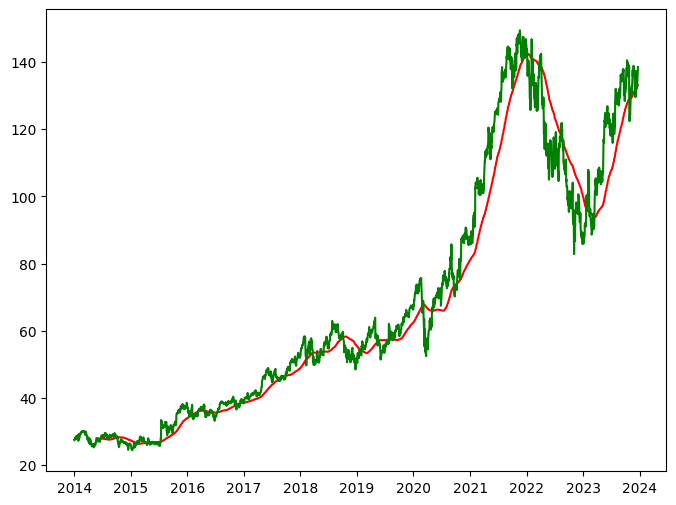

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(ma_100_days, 'r')
plt.plot(data.Close, 'g')
plt.show()

In [ ]:
ma_200_days = data.Close.rolling(200).mean()

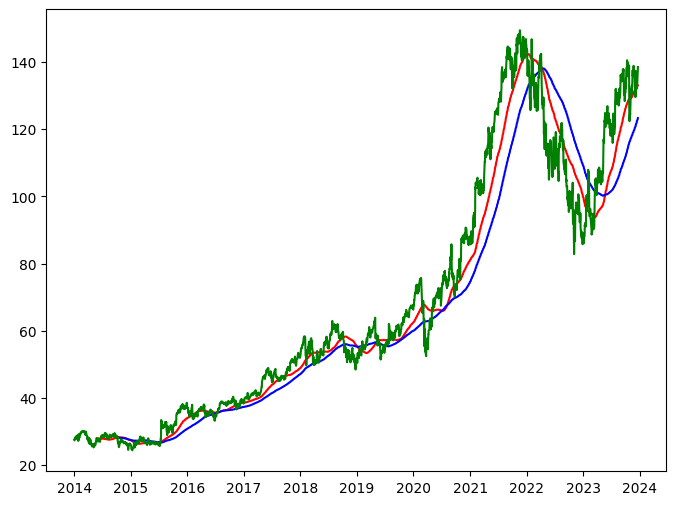

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(ma_100_days, 'r')
plt.plot(ma_200_days,'b')
plt.plot(data.Close,'g')
plt.show()

In [ ]:
data.dropna(inplace=True)

In [ ]:
data_train = pd.DataFrame(data.Close[0: int(len(data)*0.80)])
data_test = pd.DataFrame(data.Close[int(len(data)*0.80): len(data)])

In [ ]:
data_train.shape[0]

2008

In [ ]:
data_test.shape[0]

502

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [ ]:
data_train_scale = scaler.fit_transform(data_train)

In [ ]:
x = []
y = []

for i in range(100, data_train_scale.shape[0]):
    x.append(data_train_scale[i-100:i])
    y.append(data_train_scale[i,0])
    

In [ ]:
x, y = np.array(x), np.array(y)

In [ ]:
from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential

In [ ]:
model = Sequential()
model.add(LSTM(units = 50, activation = 'relu', return_sequences = True,
               input_shape = ((x.shape[1],1))))
model.add(Dropout(0.2))

model.add(LSTM(units = 60, activation='relu', return_sequences = True))
model.add(Dropout(0.3))

model.add(LSTM(units = 80, activation = 'relu', return_sequences = True))
model.add(Dropout(0.4))

model.add(LSTM(units = 120, activation = 'relu'))
model.add(Dropout(0.5))

model.add(Dense(units =1))

c:\Users\asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer = 'adam', loss = 'mean_squared_error')

In [ ]:
model.fit(x,y, epochs = 50, batch_size =32, verbose =1)

Epoch 1/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step - loss: 0.0288
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - loss: 0.0069
Epoch 3/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - loss: 0.0048
Epoch 4/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - loss: 0.0044
Epoch 5/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - loss: 0.0041
Epoch 6/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - loss: 0.0039
Epoch 7/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - loss: 0.0033
Epoch 8/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - loss: 0.0035
Epoch 9/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 109ms/step - loss: 0.0030
Epoch 10/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 12s 197ms/step - loss: 0.0032
Epoch 11/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 19s 166ms/step - loss: 0.0030
Epoch 12/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 158ms/step - loss: 0.0027
Epoch 13/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 165ms/step - loss: 0.0027
Epoch 14/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 115ms/step - loss: 0.0029
Epoch 15/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - loss: 0

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100, 80)        │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 536,285 (2.05 MB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 357,524 (1.36 MB)

In [ ]:
pas_100_days = data_train.tail(100)

In [ ]:
data_test = pd.concat([pas_100_days, data_test], ignore_index=True)

In [ ]:
data_test_scale  =  scaler.fit_transform(data_test)

In [ ]:
x = []
y = []

for i in range(100, data_test_scale.shape[0]):
    x.append(data_test_scale[i-100:i])
    y.append(data_test_scale[i,0])
x, y = np.array(x), np.array(y)

In [ ]:
print(x[0],y)

[[0.78102176]
 [0.78534341]
 [0.7816017 ]
 [0.79516171]
 [0.79659028]
 [0.8109607 ]
 [0.81236684]
 [0.80631246]
 [0.81672603]
 [0.81697137]
 [0.8245587 ]
 [0.80052515]
 [0.78965751]
 [0.79476783]
 [0.81743254]
 [0.85704216]
 [0.87636704]
 [0.88457092]
 [0.87226807]
 [0.90838201]
 [0.92205325]
 [0.92194179]
 [0.92759452]
 [0.90344975]
 [0.91172138]
 [0.92278973]
 [0.91333556]
 [0.91378207]
 [0.86926308]
 [0.89223309]
 [0.89135493]
 [0.91813302]
 [0.90574869]
 [0.86245733]
 [0.82606074]
 [0.83542611]
 [0.85464686]
 [0.86785739]
 [0.87985517]
 [0.86301461]
 [0.78391529]
 [0.75917524]
 [0.74049736]
 [0.7880582 ]
 [0.7479286 ]
 [0.78381093]
 [0.80132092]
 [0.82856795]
 [0.84151803]
 [0.82353956]
 [0.79178504]
 [0.80944378]
 [0.86169109]
 [0.86560376]
 [0.88472724]
 [0.89754389]
 [0.87661215]
 [0.88205021]
 [0.82022949]
 [0.82243094]
 [0.83580534]
 [0.93630534]
 [0.93186491]
 [0.96372288]
 [0.89683006]
 [0.92790761]
 [0.94169808]
 [0.96985989]
 [0.97816058]
 [0.97980498]
 [0.9782725 ]
 [0.93

In [ ]:
y_predict = model.predict(x)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step


In [ ]:
scale =1/scaler.scale_

In [ ]:
y_predict = y_predict*scale

In [ ]:
y = y*scale

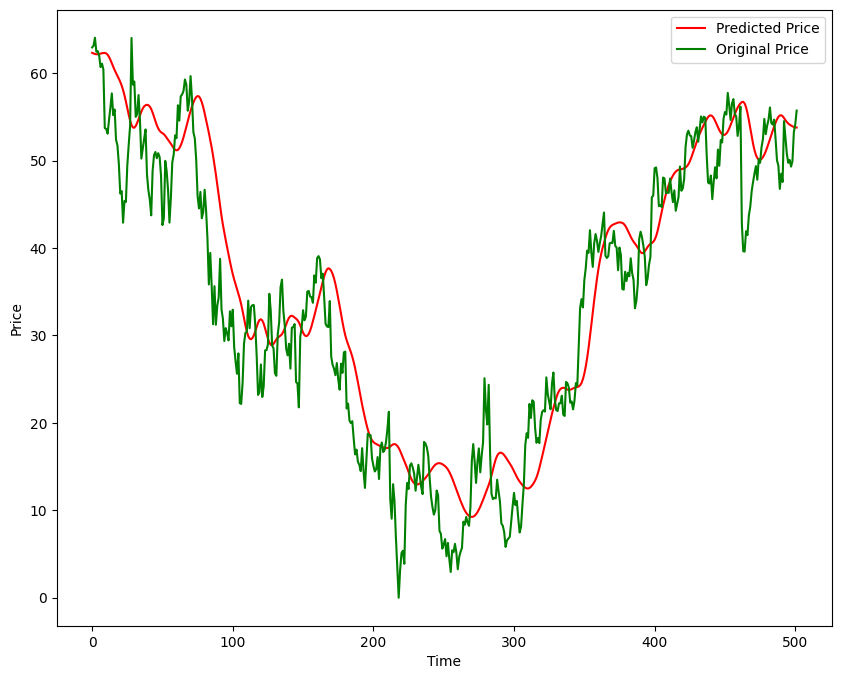

In [ ]:
plt.figure(figsize=(10,8))
plt.plot(y_predict, 'r', label = 'Predicted Price')
plt.plot(y, 'g', label = 'Original Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

In [ ]:
model.save('Stock Predictions Model.keras')